# Klasifikasi berita

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

file_path = "Berita.csv"
df = pd.read_csv(file_path)
print("Jumlah data:", len(df))
print(df.head())

# Preprocessing 
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)       
    text = re.sub(r'[^a-zA-Z\s]', '', text)                   
    text = re.sub(r'\s+', ' ', text).strip()                  
    
    tokens = word_tokenize(text)                              
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  
    stemmed = [stemmer.stem(t) for t in tokens]              
    return ' '.join(stemmed)

print(" Melakukan preprocessing")
tqdm.pandas()
df['text_clean'] = df['berita'].progress_apply(preprocess_text)
df['kategori'] = df['kategori'].astype(str)
print("\nContoh hasil preprocessing:")
print(df[['judul', 'text_clean', 'kategori']].head())


[nltk_data] Downloading package punkt to C:\Users\Mukti
[nltk_data]     Hendra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Mukti
[nltk_data]     Hendra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Jumlah data: 1500
   No                                              judul  \
0   1  Airlangga Harap Kenaikan UMP Tingkatkan Daya B...   
1   2  PT SIER Beri Penghargaan untuk 50 Tenant Terba...   
2   3  Prabowo Bakal Bentuk Kementerian Penerimaan Ne...   
3   4  Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...   
4   5  Pemerintah Segera Bentuk Satgas PHK Usai Tetap...   

                                              berita  \
0  Menteri Koordinator (Menko) Bidang Perekonomia...   
1  Dalam rangka memeriahkan hari jadi ke-50, PT S...   
2  Wacana Presiden Prabowo Subianto akan membentu...   
3  BPJS Ketenagakerjaan dan Kementerian Agama (Ke...   
4  Pemerintah akan segera membentuk Satuan Tugas ...   

                         tanggal kategori  \
0  Minggu, 01 Des 2024 23:40 WIB  Ekonomi   
1  Minggu, 01 Des 2024 20:45 WIB  Ekonomi   
2  Minggu, 01 Des 2024 19:40 WIB  Ekonomi   
3  Minggu, 01 Des 2024 19:03 WIB  Ekonomi   
4  Minggu, 01 Des 2024 19:00 WIB  Ekonomi   

             

100%|██████████| 1500/1500 [37:03<00:00,  1.48s/it] 



Contoh hasil preprocessing:
                                               judul  \
0  Airlangga Harap Kenaikan UMP Tingkatkan Daya B...   
1  PT SIER Beri Penghargaan untuk 50 Tenant Terba...   
2  Prabowo Bakal Bentuk Kementerian Penerimaan Ne...   
3  Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...   
4  Pemerintah Segera Bentuk Satgas PHK Usai Tetap...   

                                          text_clean kategori  
0  menteri koordinator menko bidang ekonomi airla...  Ekonomi  
1  rangka riah surabaya industrial estate rungkut...  Ekonomi  
2  wacana presiden prabowo subianto bentuk bentuk...  Ekonomi  
3  bpjs ketenagakerjaan menteri agama kemenag lin...  Ekonomi  
4  perintah bentuk satu tugas putus hubung kerja ...  Ekonomi  


OSError: Cannot save file into a non-existent directory: '\content'

In [10]:
df.to_csv("Berita_preprocessed.csv", index=False)
print("\n✅ File hasil disimpan sebagai: Berita_preprocessed.csv")




✅ File hasil disimpan sebagai: Berita_preprocessed.csv


Jumlah data: 1500
   No                                              judul  \
0   1  Airlangga Harap Kenaikan UMP Tingkatkan Daya B...   
1   2  PT SIER Beri Penghargaan untuk 50 Tenant Terba...   
2   3  Prabowo Bakal Bentuk Kementerian Penerimaan Ne...   
3   4  Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...   
4   5  Pemerintah Segera Bentuk Satgas PHK Usai Tetap...   

                                              berita  \
0  Menteri Koordinator (Menko) Bidang Perekonomia...   
1  Dalam rangka memeriahkan hari jadi ke-50, PT S...   
2  Wacana Presiden Prabowo Subianto akan membentu...   
3  BPJS Ketenagakerjaan dan Kementerian Agama (Ke...   
4  Pemerintah akan segera membentuk Satuan Tugas ...   

                         tanggal kategori  \
0  Minggu, 01 Des 2024 23:40 WIB  Ekonomi   
1  Minggu, 01 Des 2024 20:45 WIB  Ekonomi   
2  Minggu, 01 Des 2024 19:40 WIB  Ekonomi   
3  Minggu, 01 Des 2024 19:03 WIB  Ekonomi   
4  Minggu, 01 Des 2024 19:00 WIB  Ekonomi   

             

c:\Users\Mukti Hendra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(



 LDA selesai - menghasilkan 10 topik.

 Evaluasi Model:
         Model   Akurasi   Presisi    Recall  F1-Score
0  Naive Bayes  0.913333  0.923535  0.913333  0.910695
1          SVM  0.900000  0.913634  0.900000  0.895848


<Figure size 800x500 with 0 Axes>

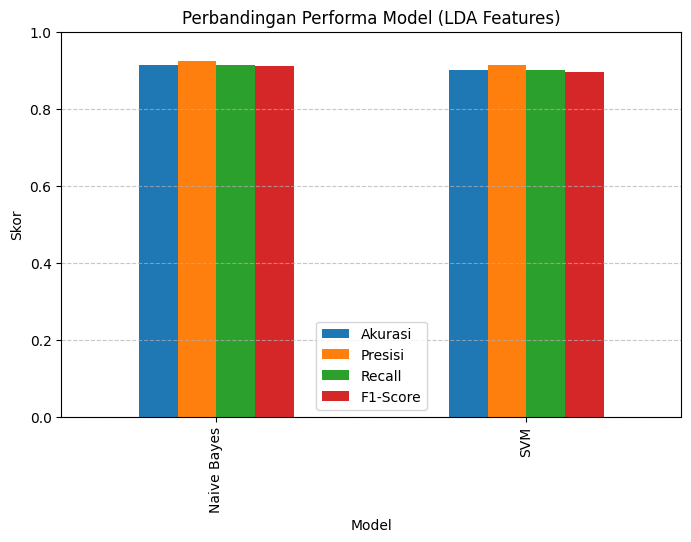


🧩 Daftar topik utama (kata-kata dominan):
Topik 1:
presiden trump yoon negara militer perintah serang suriah anggota rusia

Topik 2:
laut pagar tangerang menteri milik nelayan kkp bangun misterius ikan

Topik 3:
pangan tani beras milik laku kembang produksi hasil lpg jakarta

Topik 4:
bakar los orang pesawat angeles api air lapor korban wilayah

Topik 5:
prabowo kerja menteri perintah presiden indonesia ekonomi program anggar negara

Topik 6:
main indonesia timnas piala latih gol menit menang laga tanding

Topik 7:
makan gizi program mbg gratis suara jakarta jabat terima haji

Topik 8:
israel senjata gencat gaza indonesia hamas palestina sepakat bebas sandera

Topik 9:
duga kpk korban jalan banjir sangka warga polisi periksa orang

Topik 10:
persen harga ppn pajak indonesia minyak tarif menteri perintah uang



In [16]:
#  Load data hasil preprocessing
df = pd.read_csv("Berita_preprocessed.csv")
print("Jumlah data:", len(df))
print(df.head())

stop_words = stopwords.words('indonesian')

#  Vektorisasi teks untuk LDA
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=stop_words)
X_counts = vectorizer.fit_transform(df['text_clean'])

# Latent Dirichlet Allocation (LDA)
n_topics = 10
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
X_topics = lda.fit_transform(X_counts)

print(f"\n LDA selesai - menghasilkan {n_topics} topik.")

# Split data latih & uji
X_train, X_test, y_train, y_test = train_test_split(
    X_topics, df['kategori'], test_size=0.2, random_state=42, stratify=df['kategori']
)

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Model 2: SVM
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Evaluasi performa
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'Model': model_name, 'Akurasi': acc, 'Presisi': prec, 'Recall': rec, 'F1-Score': f1}

results = []
results.append(evaluate_model(y_test, y_pred_nb, "Naive Bayes"))
results.append(evaluate_model(y_test, y_pred_svm, "SVM"))

# 10️⃣ Tampilkan hasil evaluasi dalam tabel
eval_df = pd.DataFrame(results)
print("\n Evaluasi Model:")
print(eval_df)

# 11️⃣ Visualisasi perbandingan performa
plt.figure(figsize=(8,5))
eval_df.set_index('Model')[['Akurasi','Presisi','Recall','F1-Score']].plot(kind='bar', figsize=(8,5))
plt.title("Perbandingan Performa Model (LDA Features)")
plt.ylabel("Skor")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 12️⃣ (Opsional) Tampilkan topik LDA
def display_topics(model, feature_names, no_top_words):
    for idx, topic in enumerate(model.components_):
        print(f"Topik {idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("")

print("\n🧩 Daftar topik utama (kata-kata dominan):")
display_topics(lda, vectorizer.get_feature_names_out(), 10)


In [15]:
import numpy as np
import pandas as pd

# ============================================================
# 🔹 PROPORSI TOPIK DALAM DOKUMEN
# ============================================================
doc_topic_df = pd.DataFrame(X_topics, 
                            columns=[f"Topik_{i+1}" for i in range(n_topics)])
doc_topic_df["Kategori"] = df["kategori"]

print("\n📄 Proporsi Topik dalam Setiap Dokumen (Document-Topic Distribution):")
print(doc_topic_df.head())

# Simpan ke file CSV (opsional)
doc_topic_df.to_csv("Proporsi_Topik_Dalam_Dokumen.csv", index=False)
print("✅ Disimpan ke: Proporsi_Topik_Dalam_Dokumen.csv")

# ============================================================
# 🔹 PROPORSI KATA DALAM TOPIK
# ============================================================
topic_word = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]
vocab = vectorizer.get_feature_names_out()

topic_word_df = pd.DataFrame(topic_word.T, 
                             index=vocab, 
                             columns=[f"Topik_{i+1}" for i in range(n_topics)])

print("\n🧩 Proporsi Kata dalam Tiap Topik (Topic-Word Distribution):")
print(topic_word_df.head(10))  # tampilkan 10 kata pertama

# Simpan ke file CSV (opsional)
topic_word_df.to_csv("Proporsi_Kata_Dalam_Topik.csv")
print("✅ Disimpan ke: Proporsi_Kata_Dalam_Topik.csv")



📄 Proporsi Topik dalam Setiap Dokumen (Document-Topic Distribution):
    Topik_1   Topik_2   Topik_3   Topik_4   Topik_5   Topik_6   Topik_7  \
0  0.000337  0.000337  0.008592  0.130761  0.405655  0.000337  0.000337   
1  0.000281  0.000281  0.573253  0.000281  0.346295  0.000281  0.000281   
2  0.000335  0.000335  0.000335  0.000335  0.505755  0.000335  0.046971   
3  0.000457  0.000457  0.012562  0.000457  0.851956  0.000457  0.043255   
4  0.000422  0.000422  0.203044  0.000422  0.581054  0.000422  0.000422   

    Topik_8   Topik_9  Topik_10  Topik_11  Topik_12  Topik_13  Topik_14  \
0  0.000337  0.000337  0.435028  0.016597  0.000337  0.000337  0.000337   
1  0.000281  0.000281  0.077076  0.000281  0.000281  0.000281  0.000281   
2  0.234710  0.000335  0.141094  0.000335  0.040926  0.000335  0.000335   
3  0.087204  0.000457  0.000457  0.000457  0.000457  0.000457  0.000457   
4  0.022055  0.000422  0.157107  0.032521  0.000422  0.000422  0.000422   

   Topik_15 Kategori  
0  0.